# Fraud Transaction Analysis
A data cleaning and exploratory analysis project using Python on UPI transaction data, examining fraud patterns by bank and device type.

In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv(r"C:\Users\utkarsh\Downloads\fraud_dataset.csv")

# Data Understanding And Validation

In [2]:
print(df.head())

                         transaction_id           user_id  \
0  7d4e9561-000c-44c8-84e4-54af2c4ac209        michelle89   
1  fbf88cde-dc62-4f36-ac10-a1b1fd771793         eguerrero   
2  d746c963-baaa-46a0-80f4-b050e14e1c7d  alexanderpatrick   
3  e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244         timothy32   
4  34309820-3aec-4fa4-9518-03437830e1e0      billycalhoun   

                            merchant_id       amount timestamp  \
0  8bdff36c-efba-4260-a801-8bd36f0f2eb0  1960.754748   18:27.7   
1  a28f2b48-5423-4eb6-9018-00e6e55410af  4593.854621   34:55.5   
2  ce4ed336-6b99-42f2-88ca-dba320b8a96f  1949.587163   49:42.8   
3  3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3  2825.569899   16:29.9   
4  2e34ad70-ec10-4ac1-895e-2773c6246f62  6509.628443   39:44.7   

                                         description  \
0                 Payment to Lee-Warren for products   
1  Payment to Wright, Johnson and Parker for prod...   
2                 Payment to Hanson Ltd for products   
3    Payment

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26393 entries, 0 to 26392
Data columns (total 65 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   transaction_id                           26393 non-null  str    
 1   user_id                                  26393 non-null  str    
 2   merchant_id                              26393 non-null  str    
 3   amount                                   26393 non-null  float64
 4   timestamp                                26393 non-null  str    
 5   description                              26393 non-null  str    
 6   device_id                                26393 non-null  str    
 7   ip_address                               26393 non-null  str    
 8   location                                 26393 non-null  str    
 9   session_duration                         26393 non-null  int64  
 10  authentication_attempts                  26393 non-null  

In [4]:
print(df.dtypes)

transaction_id                           str
user_id                                  str
merchant_id                              str
amount                               float64
timestamp                                str
                                      ...   
social_media_presence                    str
handle_registration_pattern              str
handle_to_description_consistency      int64
handle_verification_status               str
is_fraud                               int64
Length: 65, dtype: object


In [5]:
print(df.describe())

             amount  session_duration  authentication_attempts  \
count  26393.000000      26393.000000             26393.000000   
mean    4865.367115        161.625014                 1.108589   
std     5720.508492         89.453321                 0.543179   
min      139.267664          5.000000                 1.000000   
25%     2425.484162         88.000000                 1.000000   
50%     3685.574962        156.000000                 1.000000   
75%     5239.994313        231.000000                 1.000000   
max    49970.158580        600.000000                 5.000000   

       receiver_account_age  receiver_transaction_history  \
count          26393.000000                  26393.000000   
mean             150.288486                     42.332588   
std              161.297565                     31.559755   
min                0.000000                      0.000000   
25%               13.000000                     11.000000   
50%               96.000000            

In [6]:
print(df.shape)

(26393, 65)


In [7]:
print(df.isnull().sum())

transaction_id                       0
user_id                              0
merchant_id                          0
amount                               0
timestamp                            0
                                    ..
social_media_presence                0
handle_registration_pattern          0
handle_to_description_consistency    0
handle_verification_status           0
is_fraud                             0
Length: 65, dtype: int64


In [8]:
missing = df.isnull().sum()
print(missing[missing > 0])

url_referrer           25636
request_description    25661
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [10]:
text_columns = df.select_dtypes(include = 'object').columns

for col in text_columns:
    print(col, df[col].unique()) 

transaction_id <StringArray>
['7d4e9561-000c-44c8-84e4-54af2c4ac209',
 'fbf88cde-dc62-4f36-ac10-a1b1fd771793',
 'd746c963-baaa-46a0-80f4-b050e14e1c7d',
 'e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244',
 '34309820-3aec-4fa4-9518-03437830e1e0',
 '766452f2-3b87-4acb-8892-b93352999ccf',
 '31de092d-42dc-49e1-9240-e3de481c28cb',
 '5a978142-7a92-4e57-942e-f993c966aaee',
 '007de78c-9f8b-4711-9c88-0ae51bacc3a1',
 'ce10415b-7124-4e40-97eb-b8046d53f132',
 ...
 'b22172d8-bee4-42da-bf54-ed06c0baf81e',
 'b8c6a805-b604-461f-9bbb-5f84d78194a3',
 'ad8612f7-5c77-48fc-9111-de73a4021243',
 'ad4c2045-dfcc-473c-99f7-f7ebe6d24a38',
 'f5416647-f7f7-450e-9992-4001d24c523f',
 'a9fcaaa8-87f6-4f9e-9a28-6e10928970d9',
 '5034b135-5795-4ae6-ada3-81dd1754e72e',
 '0a9256ed-66d6-4a68-a571-1ad8752b84e0',
 'f683c6fa-da49-439a-95e0-b272bda08724',
 '63bbf9a4-5a96-4659-9ac7-f14c4c39135b']
Length: 26393, dtype: str
user_id <StringArray>
[      'michelle89',        'eguerrero', 'alexanderpatrick',
        'timothy32',     'billycalhou

C:\Users\utkarsh\AppData\Local\Temp\ipykernel_2304\3797925155.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include = 'object').columns


# Data Cleaning

In [11]:
df['url_referrer'] = df['url_referrer'].fillna("Not Applicable")
df['request_description'] = df['request_description'].fillna("Not Applicable")

In [12]:
print(df['url_referrer'].isnull().sum())
print(df['request_description'].isnull().sum())


0
0


In [13]:
df = df.drop(columns = ['social_media_presence', 'relationship_to_requester'])

In [14]:
print(df.shape)

(26393, 63)


# Data Analysis

In [15]:
df.groupby('handle_verification_status')['is_fraud'].mean()

handle_verification_status
unverified    1.0
verified      0.0
Name: is_fraud, dtype: float64

In [16]:
df.groupby('authorization_method')['is_fraud'].mean()

authorization_method
otp    1.000000
pin    0.148558
Name: is_fraud, dtype: float64

In [17]:
df.groupby('pin_entry_method')['is_fraud'].mean()

pin_entry_method
manual    0.12496
pasted    1.00000
Name: is_fraud, dtype: float64

In [18]:
df.groupby('session_source')['is_fraud'].mean()

session_source
app     0.147761
link    1.000000
Name: is_fraud, dtype: float64

In [19]:
df.groupby('recent_app_installs')['is_fraud'].mean()

recent_app_installs
['screen_mirroring_app']    1.000000
[]                          0.149916
Name: is_fraud, dtype: float64

In [20]:
df.groupby('permissions_granted')['is_fraud'].mean()

permissions_granted
['camera', 'screen_capture']    1.000000
[]                              0.149916
Name: is_fraud, dtype: float64

In [21]:
df.groupby('recognized_screen_sharing_apps')['is_fraud'].mean()

recognized_screen_sharing_apps
['screen_mirroring_app']    1.000000
[]                          0.149916
Name: is_fraud, dtype: float64

In [22]:
df['amount_group'] = pd.cut(df['amount'], bins = [0,10000,20000,30000,40000,50000])
df.groupby('amount_group')['is_fraud'].mean()

amount_group
(0, 10000]        0.129796
(10000, 20000]    0.991749
(20000, 30000]    1.000000
(30000, 40000]    1.000000
(40000, 50000]    1.000000
Name: is_fraud, dtype: float64

In [23]:
df['screen_active_time_group'] = pd.cut(df['screen_active_time'], bins = [0,120,180,240,300,360,420,480,540,600,660,720,780,840,900])
df.groupby('screen_active_time_group')['is_fraud'].mean()

screen_active_time_group
(0, 120]      0.891111
(120, 180]    0.191764
(180, 240]    0.185292
(240, 300]    0.197552
(300, 360]    0.118773
(360, 420]    0.124185
(420, 480]    0.120585
(480, 540]    0.109461
(540, 600]    0.124054
(600, 660]    1.000000
(660, 720]    1.000000
(720, 780]    1.000000
(780, 840]    1.000000
(840, 900]    1.000000
Name: is_fraud, dtype: float64

# Key Findings

This analysis examined 26,393 UPI transactions (17.2% overall fraud rate) 
to identify behavioral and transactional signals associated with fraud.

1. **Handle verification is a near-perfect fraud indicator.** Every fraud 
   transaction (100%) involved an unverified UPI handle, while every 
   verified-handle transaction was legitimate (0% fraud).

2. **Screen mirroring apps strongly indicate fraud.** All 692 transactions 
   where a screen mirroring app was installed (with matching camera/screen-
   capture permissions) were fraudulent — consistent with known remote-access 
   scam tactics where victims are tricked into installing screen-sharing apps.

3. **OTP-based authorization carries far higher risk than PIN.** 100% of 
   OTP-authorized transactions were fraud, compared to ~14.9% for PIN-based 
   authorization.

4. **Pasted PINs are a strong fraud signal.** 100% of transactions where the 
   PIN was pasted (rather than manually typed) were fraudulent, versus ~12.5% 
   for manually entered PINs — suggesting stolen or bot-entered PINs.

5. **Link-based sessions show much higher fraud than in-app sessions.** 
   100% of transactions starting from a link were fraud, versus ~14.8% for 
   transactions started directly in the app.

6. **Transaction amount is strongly linked to fraud above ₹10,000.** 
   Transactions under ₹10,000 showed a ~13% fraud rate, while nearly all 
   transactions above ₹10,000 (99–100%) were fraudulent.

7. **Screen active time shows a mixed pattern.** Fraud rate was low and 
   stable (10–19%) for moderate screen-active durations (120–599 seconds), 
   but rose sharply at both very short (<120s) and very long (600s+) 
   durations — worth further investigation with more data.


# Business Recommendation
Transactions combining any of the top signals — 
1. Unverified handle
2. OTP authorization
3. Pasted PIN
4. Link-based session start
5. Screen mirroring app activity
- These should be flagged for additional verification before 
processing, particularly for amounts above ₹10,000.

# Data Visualization

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

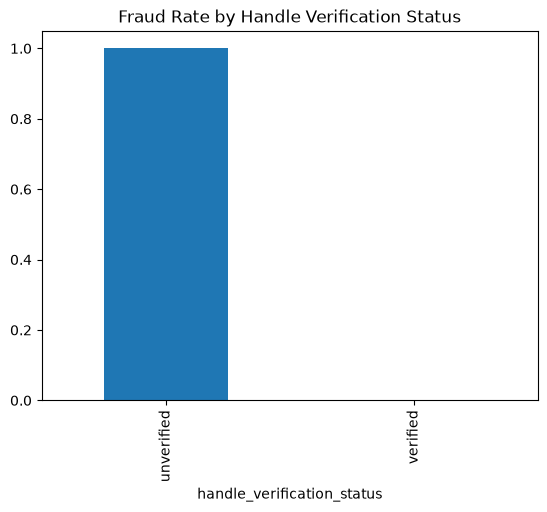

In [25]:
df.groupby('handle_verification_status')['is_fraud'].mean().plot(kind='bar')
plt.title('Fraud Rate by Handle Verification Status')
plt.show()


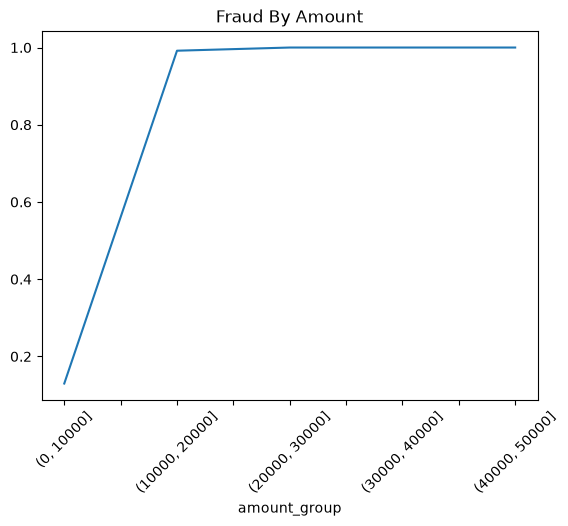

In [44]:
df['amount_group'] = pd.cut(df['amount'], bins = [0,10000,20000,30000,40000,50000])
df.groupby('amount_group')['is_fraud'].mean().plot(kind='line')
plt.title('Fraud By Amount')
plt.xticks(rotation = 45)
plt.show()

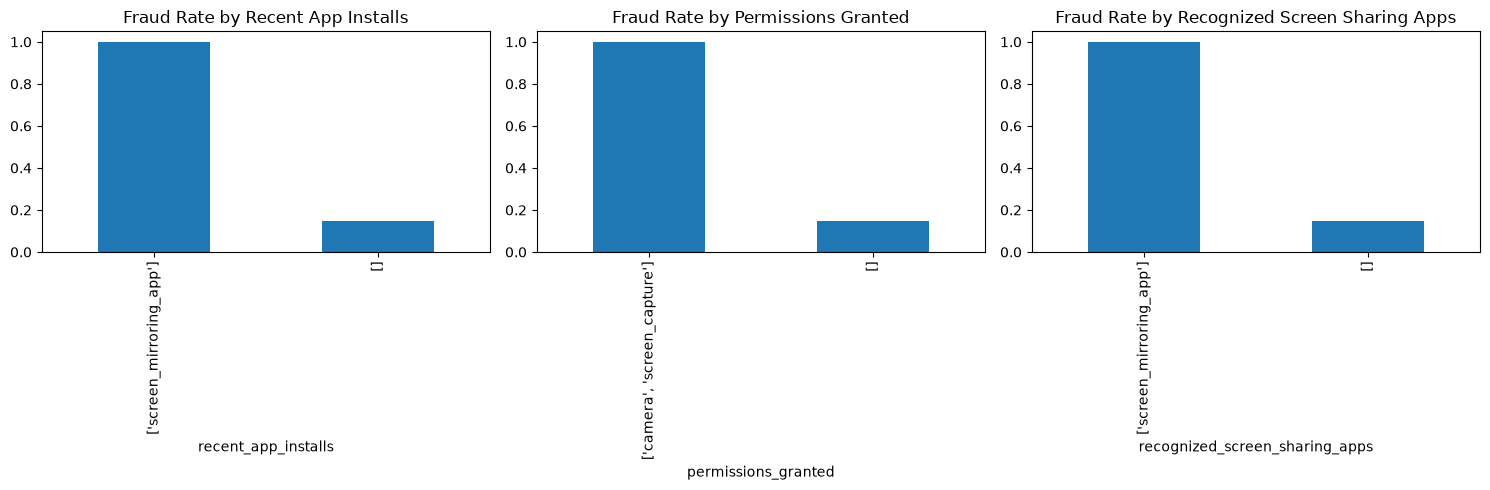

In [43]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))

df.groupby('recent_app_installs')['is_fraud'].mean().plot(kind='bar',ax=axis[0], title= 'Fraud Rate by Recent App Installs')
df.groupby('permissions_granted')['is_fraud'].mean().plot(kind='bar',ax=axis[1],title= 'Fraud Rate by Permissions Granted')
df.groupby('recognized_screen_sharing_apps')['is_fraud'].mean().plot(kind='bar', ax=axis[2],title= 'Fraud Rate by Recognized Screen Sharing Apps')
plt.tight_layout()
plt.show()

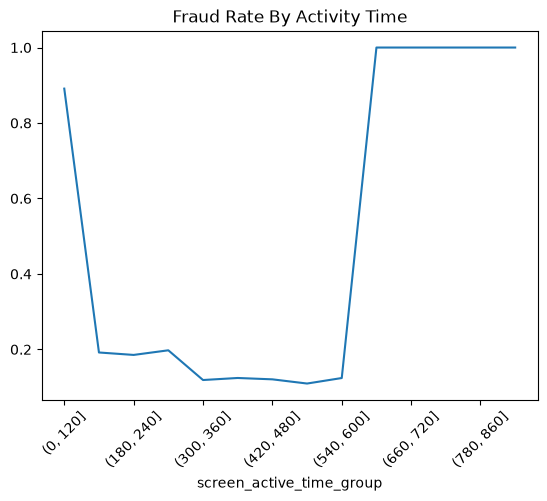

In [40]:
df['screen_active_time_group'] = pd.cut(df['screen_active_time'], bins = [0,120,180,240,300,360,420,480,540,600,660,720,780,860,900])
df.groupby('screen_active_time_group')['is_fraud'].mean().plot(kind='line')
plt.title('Fraud Rate By Activity Time')
plt.xticks(rotation = 45)
plt.show()

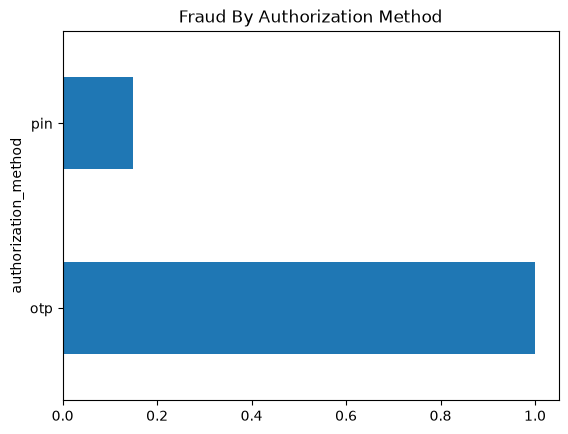

In [35]:
df.groupby('authorization_method')['is_fraud'].mean().plot(kind='barh')
plt.title('Fraud By Authorization Method')
plt.show()

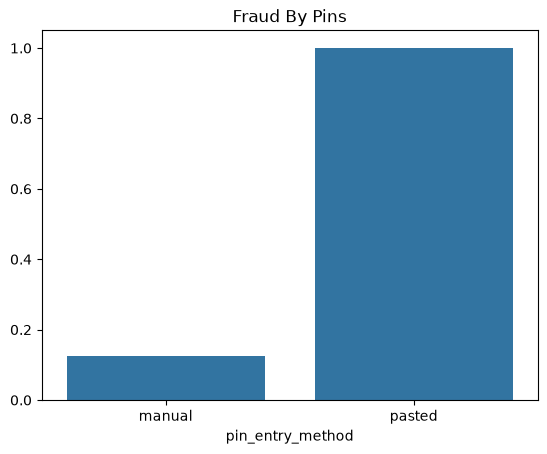

In [34]:
pin_fraud = df.groupby('pin_entry_method')['is_fraud'].mean()
sns.barplot(x=pin_fraud.index, y=pin_fraud.values)
plt.title('Fraud By Pins')
plt.show()

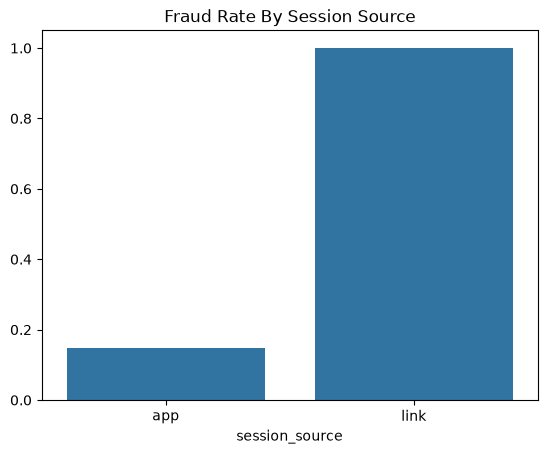

In [33]:
session_source_fraud = df.groupby('session_source')['is_fraud'].mean()
sns.barplot(x=session_source_fraud.index, y=session_source_fraud.values)
plt.title('Fraud Rate By Session Source')
plt.show()